In [1]:
from matplotlib import cm
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
import datetime
import calendar
from sklearn import preprocessing

In [2]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/ur60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/tr60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)


dmax = 716

ueast = np.zeros((42,dmax))
ratiosl = np.zeros((42,dmax))

onset = np.zeros((42,dmax))
ronset = np.zeros((42,dmax))

onset_id = np.zeros(200)
ronset_id = np.zeros(210)

end = np.zeros((42,dmax))
rend = np.zeros((42,dmax))

end_id = np.zeros(200)
rend_id = np.zeros(210)

ssw = np.zeros((42,dmax))
rssw = np.zeros((42,dmax))

fponset_id = np.zeros(210)

ratio = 0.3

######################################### find out the onset date #######################################

i = 0
while(i < 42):
    j = 0
    while(j < dmax):
        if ubp[i,j] < 0:
            ueast[i,j] = 1 
        if ubp[i,j]/urp[i,j] < ratio:
            ratiosl[i,j] = 1
        j=j+1
    i=i+1

i = 0
n = 0
nn = 0
m = 0
mm = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):
        if ubp[i,j] < 0 and ueast[i,j-1] == 0:
            onset[i,j] = 1
            onset_id[n] = t
            n=n+1
            #print(date[i][j])
        elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
            end[i,j] = 1
            end_id[m] = t
            m=m+1
        elif j == dmax-1:
            if ueast[i,j] == 1:
                end[i,j] = 1
                end_id[m] = t
                m=m+1
        if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
            ronset[i,j] = 1
            ronset_id[nn] = t
            nn=nn+1
        elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
            rend[i,j] = 1
            rend_id[mm] = t
            mm=mm+1
        elif j == dmax-1:
            if ratiosl[i,j] == 1:
                rend[i,j] = 1
                rend_id[mm] = t
                mm=mm+1
        t=t+1
        j=j+1
    i=i+1


######################################### exclude some events #######################################

n = 1
while(n<210):
    if rend_id[n]-ronset_id[n]<2*4:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1


#the interval of the start of an event and the end of the last event should be larger than 10 days
n = 1
while(n<200):
    if (onset_id[n]-end_id[n-1])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1 
n = 2
while(n<200):
    if (onset_id[n]-end_id[n-2])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 1
while(n<210):
    if (ronset_id[n]-rend_id[n-1])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1 
n = 2
while(n<210):
    if (ronset_id[n]-rend_id[n-2])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

#there shouldn't be a new event shorter than 20 days
n = 1
while(n<200):
    if onset_id[n]-onset_id[n-1]<20*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 3
while(n<210):
    if ronset_id[n]-ronset_id[n-3]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

n = 2
while(n<210):
    if ronset_id[n]-ronset_id[n-2]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1
    
n = 1
while(n<210):
    if ronset_id[n]-ronset_id[n-1]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1  

#the event lasts till the end should be excluded
n = 1
while(n<200):
    if end_id[n]%(dmax-1)==0:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

n = 1
while(n<210):
    if rend_id[n]%(dmax-1)==0:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1

#an event should at least be longer than 2 days
n = 1
while(n<200):
    if end_id[n]-onset_id[n]<2*4:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1


#exclude 3 events
n = 1
while(n<200):
    if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

    
fp=0
tp=0
fn=0
fpb=0

######################################### print out the date #######################################

barplot = np.zeros(6)

i = 0
n = 0
c = 0
while(i < 42):
    j = 1
    while(j < dmax):
        if onset[i,j] == 1:      #ubar<0
            if onset_id[n] == 0: #ubar<0 but there's no SSW
                True
            else:                #there is an SSW
                print(date[i][j])
                
                if date[i][j][5:7] == '11':
                    barplot[0] = barplot[0]+1
                elif date[i][j][5:7] == '12':
                    barplot[1] = barplot[1]+1
                elif date[i][j][5:7] == '01':
                    barplot[2] = barplot[2]+1
                elif date[i][j][5:7] == '02':
                    barplot[3] = barplot[3]+1                    
                elif date[i][j][5:7] == '03':
                    barplot[4] = barplot[4]+1                     
                elif date[i][j][5:7] == '04':
                    barplot[5] = barplot[5]+1                     
                
                if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
                    tp=tp+1
#                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
#                    fn=fn+1                
                c=c+1            #how many SSWs
            n=n+1                #the size of onset_id        
        j=j+1
    i=i+1

print('####################################')

i = 0
nn = 0
cc = 0
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1:      #ubar/uref<0.3
            if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
                True
            else:
                #print(date[i][j])
                cc=cc+1            #how many rSSWs
            nn=nn+1                #the size of onset_id       
        j=j+1
    i=i+1


    
######################################### mark each day of ssw #######################################
i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):       
        if t>=onset_id[n] and t<=end_id[n]:
            ssw[i,j] = 1
        if end[i,j]==1:
            n=n+1                #the size of onset_id   
        if t>=ronset_id[nn] and t<=rend_id[nn]:
            rssw[i,j] = 1
        if rend[i,j]==1:
            nn=nn+1                #the size of onset_id  
        t=t+1
        j=j+1
    i=i+1
    
print('####################################')
######################################### find out false positive #######################################
nn = 0
fponset_id=ronset_id
while(nn < 210):
    n = 0
    while(n < 200):
        if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
            fponset_id[nn]=0
        elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
            fponset_id[nn]=0
        n=n+1
    nn=nn+1

i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1: 
            if fponset_id[nn] != 0:      #ubar/uref<0.3
                fp=fp+1
                if ubp[i,j+5]<ubp[i,j]:
                    fpb=fpb+1
            nn=nn+1
        j=j+1
    i=i+1


print('true positive:'+str(tp))
print('total ssws amount:'+str(c))
print('false positive:'+str(fp))
print('false positive but vortex decreasing:'+str(fpb))




height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

filename1 = '/scratch/smliu01/1d_model/archive/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/scratch/smliu01/1d_model/archive/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/scratch/smliu01/1d_model/archive/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb

uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)


print('done')

(124, 12, 43)
(124, 12, 43)
(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2000/03/19/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2018/02/11/18
2019/01/19/18
2021/01/05/00
####################################
####################################
true positive:22
total ssws amount:22
false positive:44
false positive but vortex decreasing:39
48000.0
10000.0
(97, 124, 12, 43)
(97, 124, 12)
done


In [3]:
model = 'a_onlyup'

In [4]:
file = '/scratch/smliu01/1d_model/climatechange/urad/'+model+'/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
ubar = ncin.variables['ubar']
ubar = np.array(ubar)
ncin.close()
print(ubar.shape)

file = '/scratch/smliu01/1d_model/climatechange/urad/'+model+'/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fawa = ncin.variables['fawa']
fawa = np.array(fawa)
ncin.close()
print(fawa.shape)

file = '/scratch/smliu01/1d_model/climatechange/urad/'+model+'/urout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
uref = ncin.variables['uref']
uref = np.array(uref)
ncin.close()
print(uref.shape)

file = '/scratch/smliu01/1d_model/climatechange/urad/'+model+'/fzout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fz = ncin.variables['fz']
fz = np.array(fz)
ncin.close()
print(fz.shape)

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

hhh = np.arange(0,501,1)*0.1+10.

yr = 1000   # 42 for 42 years, 10 for 10 years

# # Reshape ubar, fawa, uref to (1001, 42, 320)
ubar_eachyear = ubar.reshape((501, yr, 160))
fawa_eachyear = fawa.reshape((501, yr, 160))
uref_eachyear = uref.reshape((501, yr, 160))
fz_eachyear = fz.reshape((501, yr, 160))

for i in range(501):
    fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)


(501, 160000)
(501, 160000)
(501, 160000)
(501, 160000)
48000.0
10000.0


In [5]:
# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/uout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# ubar = ncin.variables['ubar']
# ubar = np.array(ubar)
# ncin.close()
# print(ubar.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/aout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# fawa = ncin.variables['fawa']
# fawa = np.array(fawa)
# ncin.close()
# print(fawa.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/urout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# uref = ncin.variables['uref']
# uref = np.array(uref)
# ncin.close()
# print(uref.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/fzout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# fz = ncin.variables['fz']
# fz = np.array(fz)
# ncin.close()
# print(fz.shape)

# height = np.zeros(97)
# plev = np.zeros(97)
# h1d = np.zeros(381)
# dz = 500.
# hh = 7000.
# dz1d = 100
# for k in range(97):
#     height[k] = k*dz
#     plev[k] = 1000*np.exp(-height[k]/hh)
# for k in range(381):
#     h1d[k] = dz1d*k+10000.

# print(height[96])
# print(h1d[0])

# hhh = np.arange(0,1001,1)*0.1+10.



# # # Reshape ubar, fawa, uref to (1001, 42, 320)
# ubar_eachyear = ubar.reshape((1001, 42, 320))
# fawa_eachyear = fawa.reshape((1001, 42, 320))
# uref_eachyear = uref.reshape((1001, 42, 320))
# fz_eachyear = fz.reshape((1001, 42, 320))

# for i in range(1001):
#     fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)




In [6]:
# # Interpolate fawa, ubar, and uref to 992 dimensions
# from scipy.interpolate import interp1d

# # Get current dimensions
# current_dim = fawa.shape[1]
# target_dim = 992

# # Create interpolation function
# x_old = np.linspace(0, 1, current_dim)
# x_new = np.linspace(0, 1, target_dim)

# # Interpolate fawa to 992 dimensions
# fawa_interp = np.zeros((fawa.shape[0], target_dim))
# for i in range(fawa.shape[0]):
#     f_interp = interp1d(x_old, fawa[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     fawa_interp[i,:] = f_interp(x_new)

# # Interpolate ubar to 992 dimensions
# ubar_interp = np.zeros((ubar.shape[0], target_dim))
# for i in range(ubar.shape[0]):
#     u_interp = interp1d(x_old, ubar[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     ubar_interp[i,:] = u_interp(x_new)

# # Interpolate uref to 992 dimensions
# uref_interp = np.zeros((uref.shape[0], target_dim))
# for i in range(uref.shape[0]):
#     ur_interp = interp1d(x_old, uref[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     uref_interp[i,:] = ur_interp(x_new)

# # Create three separate plots
# fig, (ax1, ax2, ax3) = plot.subplots(3, 1, figsize=(10, 12))

# # Plot fawa
# ax1.plot(fawa_interp[220,0:], label='fawa Interpolated (992)')
# ax1.plot(fawa_eachyr[64,0,:], label='fawa_eachyr')
# ax1.set_title('fawa Comparison')
# ax1.legend()

# # Plot ubar
# ax2.plot(ubar_interp[220,:], label='ubar Interpolated (992)')
# ax2.plot(ubar_eachyr[64,0,:], label='ubar_eachyr')
# ax2.set_title('ubar Comparison')
# ax2.legend()

# # Plot uref
# ax3.plot(uref_interp[220,:], label='uref Interpolated (992)')
# ax3.plot(uref_eachyr[64,0,:], label='uref_eachyr')
# ax3.set_title('uref Comparison')
# ax3.legend()

# plot.tight_layout()


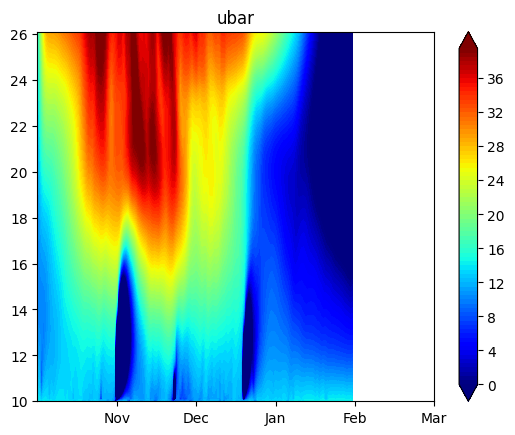

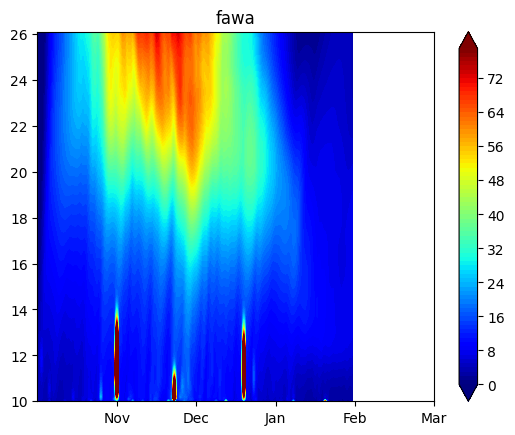

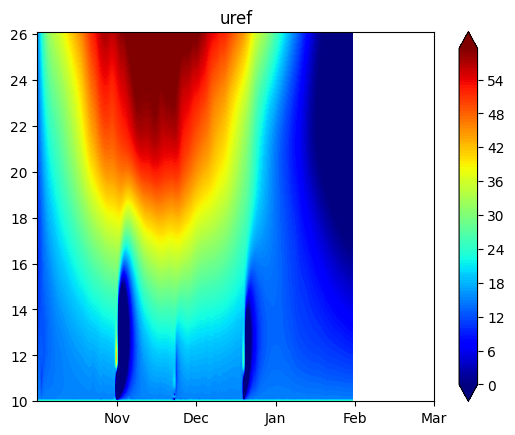

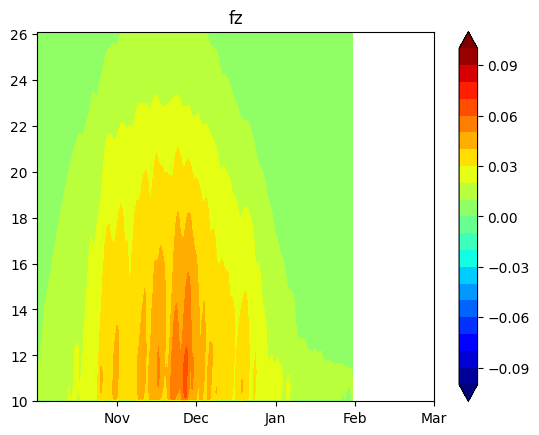

In [7]:
xx = np.arange(0,160,1) #*int(992/320)/4
zz = hhh

fig, ax = plot.subplots()
cf = ax.contourf(xx, zz[0:162], np.mean(ubar_eachyear[0:162,:,], axis=1), levels=np.arange(0, 40, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('ubar')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()   
cf = ax.contourf(xx,zz[0:162],np.mean(fawa_eachyear[0:162,:,:],axis=1), levels=np.arange(0, 80, 1), extend='both',cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fawa')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(uref_eachyear[0:162,:,],axis=1), levels=np.arange(0, 60, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('uref')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(fz_eachyear[0:162,:,:],axis=1), levels=np.arange(-0.1, 0.11, 0.01),extend= 'both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fz')
plot.colorbar(cf, ax=ax)
plot.show()


In [8]:
import numpy as np

def model_ubar_to_era5_like_inputs(
    ubar_model,          # shape = (nz, years*steps_per_year)  (501, 13440)
    level_index=110,     # 100 hPa  z 
    years=yr, # 200,
    steps_per_year=160,  #  10–5 
    start_year=1979      #  ERA5  1979-10 
):
    """
    
      ubp:  shape = (years, 992)  6-hourly Oct–May 
      date: list[list[str]]'YYYY/MM/DD/HH' ubp 
    
      -  992 = 8  × 31  × 4 /
      - ['10','11','12','01','02','03','04','05']
         31 2  31 
         31×4=124  0 
      -  SSW 
    """
    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, " years*steps_per_year "

    #  100 hPa  reshape  (years, steps_per_year)
    u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

    #  6-hourly  992 8  × 31  ×  4 
    tgt_len = 992
    src_x = np.arange(steps_per_year, dtype=float)
    tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        #  1D 
        ubp[y] = np.interp(tgt_x, src_x, u[y])

    #  date list of list
    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]  #  31 
    #  8  × 31  × 4 / = 992
    date = [[None]*tgt_len for _ in range(years)]
    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            # 10/11/12  start_year+y01–05  start_year+y+1
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    #  'YYYY/MM/DD/HH'
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1
        assert k == tgt_len

    return ubp, date

# =====  =====
ubp_model, date_model = model_ubar_to_era5_like_inputs(ubar, level_index=110, years=yr, steps_per_year=160, start_year=1979)
#  ubp_model  ubp shape=(42,992)date_model 
#  uref urp_model


In [9]:
import numpy as np

def count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=716,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=10.0,
    use_djf_only=False,
    exclude_onset_indices=None,
    #  date 
    date_2d=None,
    #  3  10  onset 
    enforce_march10_cutoff=False,
    return_debug=False,
):
    """
     10 hPa u<0  SSW 

    
    -  enforce_march10_cutoff=True  date_2d
       onset  3  10 
    """

    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    # =====  →  =====
    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    # ===== DJF only  =====
    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    # ===== 1.  u<0  =====
    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===== 2.  >= 2  &  =====
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===== 3. / end  10  & onset-onset  20  =====
    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end    = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset  = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))
        else:
            pass  #  onset_id[n]=0, end_id[n]=0

    # ===== 4.  onset 6380, 18525, 22145  =====
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1  #  t  1 
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    # ===== 5. onset  3  10  =====
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])   #  'YYYY-MM-DD...' 
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            #  3  10  month>3  (month==3  day>10)
            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


import numpy as np

# ===== 0.  =====
dmax  = 992         #  dmax
years = yr #200          #  42 
n_per_year = dmax   # 

# ubp: shape (42, dmax)  10 hPa ubar
# date: shape (42, dmax) 

# ===== 1.  ubar  1D =====
u_all_flat = ubp_model.reshape(-1)   #  flatten 0  1 ...

#  3 
#  exclude_onset_indices=None
exclude_list = [6380, 18525, 22145]

n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date_model,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)

print("total ssws amount:", n_ssw)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(1000)   #  200
end_id   = np.zeros(1000)

#  barplot 11,12,01,02,03,04
barplot = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date_model[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot[0] += 1
    elif mm == '12':
        barplot[1] += 1
    elif mm == '01':
        barplot[2] += 1
    elif mm == '02':
        barplot[3] += 1
    elif mm == '03':
        barplot[4] += 1
    elif mm == '04':
        barplot[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events:
    i_s = s // dmax
    j_s = s %  dmax
    print(date_model[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot)
print('total ssws amount:', n_ssw)


total ssws amount: 533
####################################
1980/10/21/06
1981/01/17/12
1981/10/18/00
1982/02/23/12
1984/10/15/12
1985/02/06/00
1986/02/02/06
1988/12/15/00
1990/03/06/18
1992/01/30/00
1992/10/11/18
1993/02/26/06
1994/01/06/00
1994/02/21/18
1995/02/21/12
1996/02/02/18
1997/12/05/18
1999/03/05/18
1999/12/01/06
2004/01/04/00
2005/01/23/06
2008/03/10/12
2012/10/27/12
2014/02/22/12
2014/12/01/18
2015/10/18/00
2016/02/23/06
2017/10/18/12
2018/02/22/12
2020/10/28/00
2022/10/27/18
2024/01/07/12
2026/02/01/18
2027/01/04/12
2028/02/26/12
2030/10/12/18
2030/12/09/06
2031/03/01/12
2033/02/21/00
2035/01/30/00
2035/12/16/18
2036/01/12/06
2036/02/20/06
2038/02/20/00
2038/10/18/06
2039/02/24/00
2039/12/19/00
2040/02/31/06
2042/12/21/18
2043/01/26/06
2047/02/15/18
2049/01/29/12
2050/10/21/00
2051/01/17/18
2052/02/08/00
2053/01/27/00
2054/10/13/18
2055/03/07/12
2056/10/14/12
2059/01/04/12
2060/12/13/18
2064/12/01/00
2069/02/20/00
2071/02/09/06
2072/12/07/12
2073/10/18/06
2074/02/08/00
20

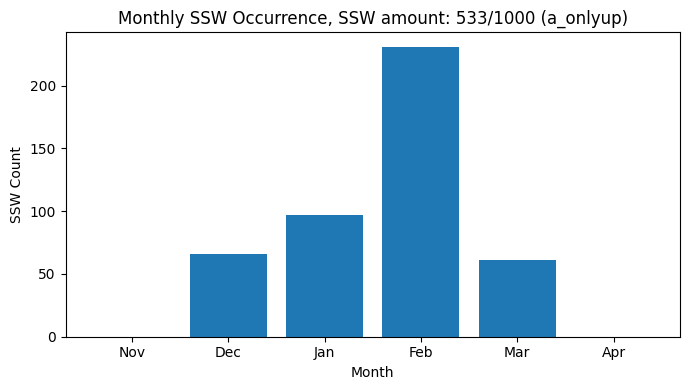

In [10]:
import matplotlib.pyplot as plt
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
plt.figure(figsize=(7,4))
plt.bar(months, barplot)
plt.xlabel('Month')
plt.ylabel('SSW Count')
plt.title('Monthly SSW Occurrence, SSW amount: ' + str(n_ssw)+'/1000' + ' ('+model+')')
plt.tight_layout()
plt.show()


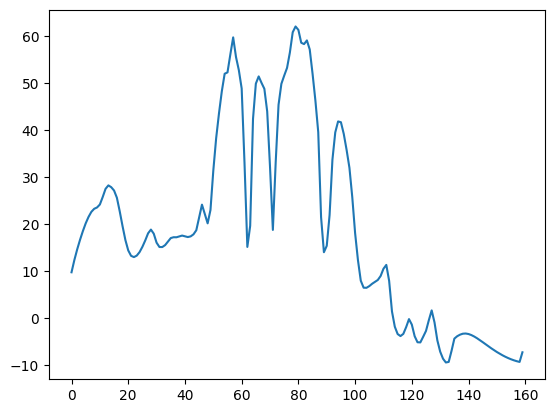

In [11]:
plot.plot(ubar_eachyear[110,0,:])

In [12]:
from scipy.interpolate import interp1d

# Assume the last dimension of *_eachyear is the one to interpolate (e.g., 320 -> 992)
target_len = 992

# --- FAWA ---
orig_len_fawa = fawa_eachyear.shape[2]
x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
x_new = np.linspace(0, 1, target_len)

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_fawa, fawa_eachyear[110, i, :], kind='linear')
    fawa_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(fawa_interp, label='2023 ver.')
#     ax.plot(fawa_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('FAWA at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UBAR ---
orig_len_ubar = ubar_eachyear.shape[2]
x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_ubar, ubar_eachyear[110, i, :], kind='linear')
    ubar_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(ubar_interp, label='2023 ver.')
#     ax.plot(ubar_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UBAR at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UREF ---
orig_len_uref = uref_eachyear.shape[2]
x_orig_uref = np.linspace(0, 1, orig_len_uref)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_uref, uref_eachyear[110, i, :], kind='linear')
    uref_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(uref_interp, label='2023 ver.')
#     ax.plot(uref_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UREF at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

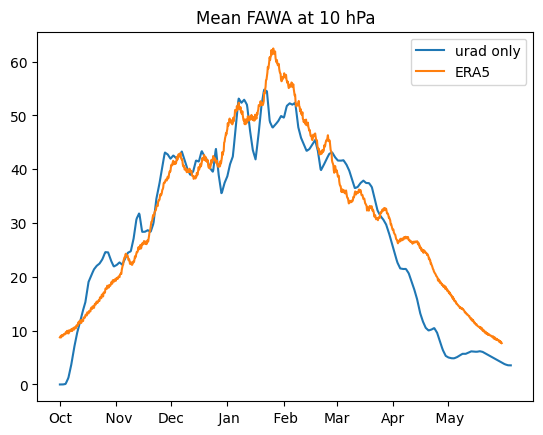

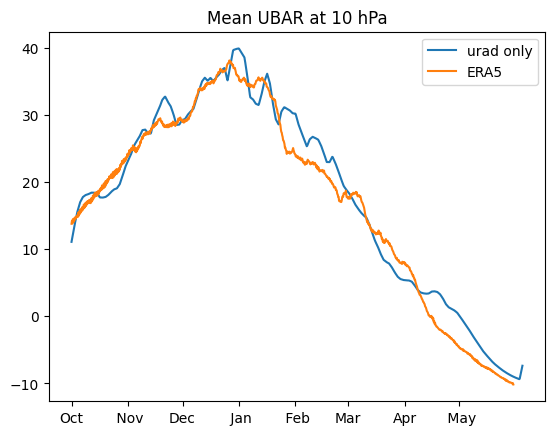

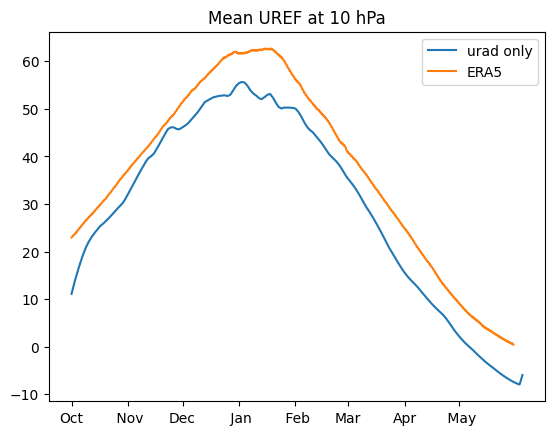

In [13]:
# Plot the mean over axis=1 for fawa, ubar, and uref (both _eachyear and _eachyr)
# For *_eachyear, interpolate the mean as well

x = np.arange(0,992,1)/4

# FAWA
fawa_eachyear_mean = np.mean(fawa_eachyear[110, 0:40, :], axis=0)
interp_func_fawa = interp1d(x_orig_fawa, fawa_eachyear_mean, kind='linear')
fawa_eachyear_mean_interp = interp_func_fawa(x_new)
fawa_eachyr_mean = np.mean(fawa_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,fawa_eachyear_mean_interp, label='urad only')
plot.plot(x,fawa_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean FAWA at 10 hPa')
plot.show()

# UBAR
ubar_eachyear_mean = np.mean(ubar_eachyear[110, 0:40, :], axis=0)
interp_func_ubar = interp1d(x_orig_ubar, ubar_eachyear_mean, kind='linear')
ubar_eachyear_mean_interp = interp_func_ubar(x_new)
ubar_eachyr_mean = np.mean(ubar_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,ubar_eachyear_mean_interp, label='urad only')
plot.plot(x,ubar_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UBAR at 10 hPa')
plot.show()

# UREF
uref_eachyear_mean = np.mean(uref_eachyear[110, 0:40, :], axis=0)
interp_func_uref = interp1d(x_orig_uref, uref_eachyear_mean, kind='linear')
uref_eachyear_mean_interp = interp_func_uref(x_new)
uref_eachyr_mean = np.mean(uref_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,uref_eachyear_mean_interp, label='urad only')
plot.plot(x,uref_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UREF at 10 hPa')
plot.show()

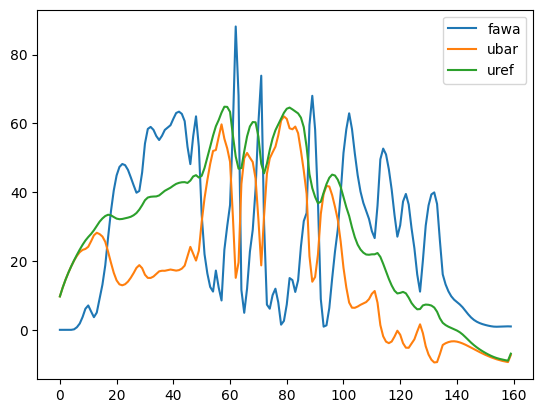

In [14]:
plot.plot(fawa_eachyear[110,0,0:228],label='fawa')
plot.plot(ubar_eachyear[110,0,0:228],label='ubar')
plot.plot(uref_eachyear[110,0,0:228],label='uref')
plot.legend()

In [15]:
# import numpy as np
# import matplotlib.pyplot as plot
# from scipy.interpolate import interp1d

# # 
# x = np.arange(0, 992, 1) / 4

# # 
# N_fawa = fawa_eachyear.shape[2]
# N_ubar = ubar_eachyear.shape[2]
# N_uref = uref_eachyear.shape[2]

# ci_factor = 2.576 #np.sqrt(N_fawa) #2.576  # 99% CI


# # figure
# fig, axes = plot.subplots(1, 3, figsize=(12,3), sharey=True)

# # ==== FAWA ====
# fawa_mean = np.mean(fawa_eachyear[110, 0:70, :], axis=0)
# fawa_std = np.std(fawa_eachyear[110, 0:70, :], axis=0)
# fawa_ci = ci_factor * fawa_std / np.sqrt(N_fawa)
# interp_fawa_mean = interp1d(x_orig_fawa, fawa_mean, kind='linear')
# interp_fawa_ci = interp1d(x_orig_fawa, fawa_ci, kind='linear')
# fawa_mean_interp = interp_fawa_mean(x_new)
# fawa_ci_interp = interp_fawa_ci(x_new)
# fawa_era5_mean = np.mean(fawa_eachyr[64, :, :], axis=0)

# axes[0].plot(x, fawa_mean_interp, label='1D model', color='C0')
# axes[0].fill_between(x, fawa_mean_interp - fawa_ci_interp, fawa_mean_interp + fawa_ci_interp, color='C0', alpha=0.3)
# axes[0].plot(x, fawa_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[0].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[0].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[0].legend()
# axes[0].set_title('Wave activity')

# # ==== UBAR ====
# ubar_mean = np.mean(ubar_eachyear[110, 0:70, :], axis=0)
# ubar_std = np.std(ubar_eachyear[110, 0:70, :], axis=0)
# ubar_ci = ci_factor * ubar_std / np.sqrt(N_ubar)
# interp_ubar_mean = interp1d(x_orig_ubar, ubar_mean, kind='linear')
# interp_ubar_ci = interp1d(x_orig_ubar, ubar_ci, kind='linear')
# ubar_mean_interp = interp_ubar_mean(x_new)
# ubar_ci_interp = interp_ubar_ci(x_new)
# ubar_era5_mean = np.mean(ubar_eachyr[64, :, :], axis=0)

# axes[1].plot(x, ubar_mean_interp, label='1D model', color='C0')
# axes[1].fill_between(x, ubar_mean_interp - ubar_ci_interp, ubar_mean_interp + ubar_ci_interp, color='C0', alpha=0.3)
# axes[1].plot(x, ubar_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[1].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[1].legend()
# axes[1].set_title('Zonal-mean zonal wind')

# # ==== UREF ====
# uref_mean = np.mean(uref_eachyear[110, 0:70, :], axis=0)
# uref_std = np.std(uref_eachyear[110, 0:70, :], axis=0)
# uref_ci = ci_factor * uref_std / np.sqrt(N_uref)
# interp_uref_mean = interp1d(x_orig_uref, uref_mean, kind='linear')
# interp_uref_ci = interp1d(x_orig_uref, uref_ci, kind='linear')
# uref_mean_interp = interp_uref_mean(x_new)
# uref_ci_interp = interp_uref_ci(x_new)
# uref_era5_mean = np.mean(uref_eachyr[64, :, :], axis=0)

# axes[2].plot(x, uref_mean_interp, label='1D model', color='C0')
# axes[2].fill_between(x, uref_mean_interp - uref_ci_interp, uref_mean_interp + uref_ci_interp, color='C0', alpha=0.3)
# axes[2].plot(x, uref_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[2].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[2].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[2].legend()
# axes[2].set_title('Reference wind')

# fig.suptitle('1979 - 2021 Climatology at 10 hPa with 99% Confidence Interval', fontsize=12)

# # 
# plot.tight_layout()
# plot.show()


In [16]:
# # Plot the distributions of fawa, ubar, and uref for both *_eachyear and *_eachyr
# # Each variable gets its own subplot, all on the same figure

# import matplotlib.pyplot as plt
# import seaborn as sns

# st_m = int(61/243*320)
# ed_m = int(151/243*320)

# st = int(61/243*992)
# ed = int(151/243*992)

# # Flatten the arrays for distribution plotting
# fawa_eachyear_flat = fawa_eachyear[110, :, :].flatten()
# fawa_eachyr_flat = fawa_eachyr[64, :, :].flatten()
# ubar_eachyear_flat = ubar_eachyear[110, :, :].flatten()
# ubar_eachyr_flat = ubar_eachyr[64, :, :].flatten()
# uref_eachyear_flat = uref_eachyear[110, :, :].flatten()
# uref_eachyr_flat = uref_eachyr[64, :, :].flatten()


# # fawa_eachyear_flat = np.mean(fawa_eachyear[220, :, st_m:ed_m],axis=0)
# # fawa_eachyr_flat = np.mean(fawa_eachyr[64, :, st:ed],axis=0)
# # ubar_eachyear_flat = np.mean(ubar_eachyear[220, :, st_m:ed_m],axis=0)
# # ubar_eachyr_flat = np.mean(ubar_eachyr[64, :, st:ed],axis=0)
# # uref_eachyear_flat = np.mean(uref_eachyear[220, :, st_m:ed_m],axis=0)
# # uref_eachyr_flat = np.mean(uref_eachyr[64, :, st:ed],axis=0)


# fig, axes = plt.subplots(3, 1, figsize=(5,7), sharex=True)

# # FAWA
# sns.kdeplot(fawa_eachyear_flat, label='FAWA urad only', fill=True, alpha=0.4, color='tab:blue', ax=axes[0])
# sns.kdeplot(fawa_eachyr_flat, label='FAWA ERA5', fill=True, alpha=0.4, color='tab:cyan', ax=axes[0])
# axes[0].legend()
# axes[0].set_title('Distribution of FAWA at 10 hPa')
# axes[0].set_ylabel('Density')
# axes[0].set_xlim(-50, 230)

# # UBAR
# sns.kdeplot(ubar_eachyear_flat, label='UBAR urad only', fill=True, alpha=0.4, color='tab:orange', ax=axes[1])
# sns.kdeplot(ubar_eachyr_flat, label='UBAR ERA5', fill=True, alpha=0.4, color='tab:olive', ax=axes[1])
# axes[1].legend()
# axes[1].set_title('Distribution of UBAR at 10 hPa')
# axes[1].set_ylabel('Density')
# axes[1].set_xlim(-50, 230)

# # UREF
# sns.kdeplot(uref_eachyear_flat, label='UREF urad only', fill=True, alpha=0.4, color='tab:green', ax=axes[2])
# sns.kdeplot(uref_eachyr_flat, label='UREF ERA5', fill=True, alpha=0.4, color='tab:purple', ax=axes[2])
# axes[2].legend()
# axes[2].set_title('Distribution of UREF at 10 hPa')
# axes[2].set_xlabel('Value')
# axes[2].set_ylabel('Density')
# axes[2].set_xlim(-50, 230)

# plt.tight_layout()
# plt.show()


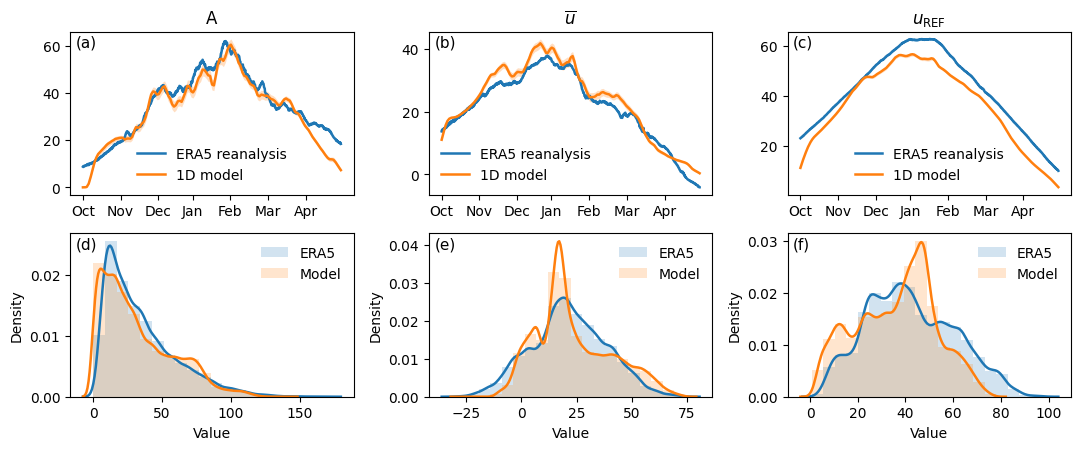

[INFO] ERA5 DJF points: 848 of 992
[INFO] FAWA model time len: 160 DJF points: 137
[INFO] UBAR model time len: 160 DJF points: 137
[INFO] UREF model time len: 160 DJF points: 137
[INFO] x_days_fawa range: 0.0 -> 211.91194968532267
[INFO] x_days_ubar  range: 0.0 -> 211.91194968532267
[INFO] x_days_uref  range: 0.0 -> 211.91194968532267


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA56 -> 992  Oct1(0d) ~ May  247.75d
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75
# DJF  Oct1  0
# DEC1 = 31 + 30               # 61
# MAR1 = DEC1 + 31 + 31 + 28    # 151

DEC1 = 0               # 61
MAR1 = 31 + 30 + 31 + 31 + 28 + 31 + 30   # 151

#  x_orig_* None
x_orig_fawa = globals().get("x_orig_fawa", None)
x_orig_ubar = globals().get("x_orig_ubar", None)
x_orig_uref = globals().get("x_orig_uref", None)

# ==========  + (yrs,time) DJF  ==========
def _auto_time_coord(n_time, x_orig_like):
    """
     time Oct1  n_time
    
    1) · ~ 0..~248 -> 
    2)  0..n_time-1          ->  0..T_days
    3)  0..1                ->  T_days
    min..max -> 0..T_days
    """
    if x_orig_like is None:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    # 
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12

    # 1)  0..~248
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        #  0..~248 
        #  0  [0, x_max-x_min]
        x_days = x_arr - x_min
        #  ERA5 
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days

    # 2)  0..1
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days

    # 3)  0..n_time-1
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days

    #  0..T_days
    return (x_arr - x_min) / span * T_days


def _djf_mask_from_days(x_days):
    """Oct1  DJF(Dec1~Mar1) """
    return (x_days >= DEC1) & (x_days < MAR1)


def _subseries_DJF(year_time_array, x_orig_like=None):
    """
    year_time_array  (years, time)
         x_orig_like        time /
    
      arr_DJF: (years, time_djf)
      x_sub :  (time_djf,) —— Oct1 /
    """
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)

    #  FalseDEC1/T_days .. MAR1/T_days
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)

    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub


# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]               # DJF  ERA5 Oct1 
x_new = x_win - DEC1              #  =>  Dec1 0~90

# ======================
#  CI
# ======================
# (level, years, time)
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    """
    mean_raw, std_raw:  DJF  (time_subset,)/
    x_days_sub       : Oct1 
    era5_mean_sub    : ERA5 DJF  (time_subset,)
    """
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")

    ci = ci_factor * std_raw / np.sqrt(n_years)

    #  model  DJF  (DEC1 + x_new)  ERA5  DJF 
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    # DJF  Dec1 
    ax.set_xticks([0, 31, 62, 90, 121, 152, 183])  # Dec1, Jan1, Feb1, Mar1
    # ax.set_xticklabels(['Dec', 'Jan', 'Feb', 'Mar 1'])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])
    ax.set_title(title)
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI DJF 
# ======================
# —— FAWA ——
fawa_model = fawa_eachyear[110, :, :]         # (years, time_model)
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.mean(fawa_model_DJF, axis=0)
fawa_std  = np.std (fawa_model_DJF, axis=0)

fawa_era5 = fawa_eachyr[64, :, :]             # (years, time_era=992)
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.mean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[0],
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='A'
)

# —— UBAR ——
ubar_model = ubar_eachyear[110, :, :]

#  -50 
ubar_model = np.where(ubar_model < -30, np.nan, ubar_model)

ubar_model_DJF, x_days_ubar = _subseries_DJF(ubar_model, x_orig_ubar)
ubar_mean = np.nanmean(ubar_model_DJF, axis=0)
ubar_std  = np.nanstd (ubar_model_DJF, axis=0)

ubar_era5 = ubar_eachyr[64, :, :]
ubar_era5 = np.where(ubar_era5 < -30, np.nan, ubar_era5)
ubar_era5_DJF = ubar_era5[:, mask_era]
ubar_era5_mean = np.nanmean(ubar_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[1],
    mean_raw=ubar_mean,
    std_raw=ubar_std,
    n_years=N_ubar,
    x_days_sub=x_days_ubar,
    era5_mean_sub=ubar_era5_mean,
    title=r'$\overline{u}$'
)

# —— UREF ——
uref_model = uref_eachyear[110, :, :]
uref_model = np.where(uref_model < 0, np.nan, uref_model)
uref_model_DJF, x_days_uref = _subseries_DJF(uref_model, x_orig_uref)
uref_mean = np.nanmean(uref_model_DJF, axis=0)
uref_std  = np.nanstd(uref_model_DJF, axis=0)

uref_era5 = uref_eachyr[64, :, :]
uref_era5 = np.where(uref_era5 < 0, np.nan, uref_era5)
uref_era5_DJF = uref_era5[:, mask_era]
uref_era5_mean = np.nanmean(uref_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[2],
    mean_raw=uref_mean,
    std_raw=uref_std,
    n_years=N_uref,
    x_days_sub=x_days_uref,
    era5_mean_sub=uref_era5_mean,
    title=r'$u_{\mathrm{REF}}$'
)

# ======================
# 3)  DJF  ERA5 Model
# ======================
def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=20, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)



fawa_model_flat = fawa_model_DJF.ravel()
fawa_era5_flat  = fawa_era5_DJF.ravel()
ubar_model_flat = ubar_model_DJF.ravel()
ubar_era5_flat  = ubar_era5_DJF.ravel()
uref_model_flat = uref_model_DJF.ravel()
uref_era5_flat  = uref_era5_DJF.ravel()

kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

# 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=11)

# ======================
# 4)  & 
# ======================
# fig.suptitle('DJF (Dec–Feb) Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation_DJF.png', dpi=600, bbox_inches='tight')
plt.show()

# —— ——
print("[INFO] ERA5 DJF points:", mask_era.sum(), "of", x.size)
print("[INFO] FAWA model time len:", fawa_model.shape[1], "DJF points:", fawa_model_DJF.shape[1])
print("[INFO] UBAR model time len:", ubar_model.shape[1], "DJF points:", ubar_model_DJF.shape[1])
print("[INFO] UREF model time len:", uref_model.shape[1], "DJF points:", uref_model_DJF.shape[1])
print("[INFO] x_days_fawa range:", float(x_days_fawa.min()), "->", float(x_days_fawa.max()))
print("[INFO] x_days_ubar  range:", float(x_days_ubar.min()),  "->", float(x_days_ubar.max()))
print("[INFO] x_days_uref  range:", float(x_days_uref.min()),  "->", float(x_days_uref.max()))


ctl: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160
upper: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160
low-: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160
low+: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160


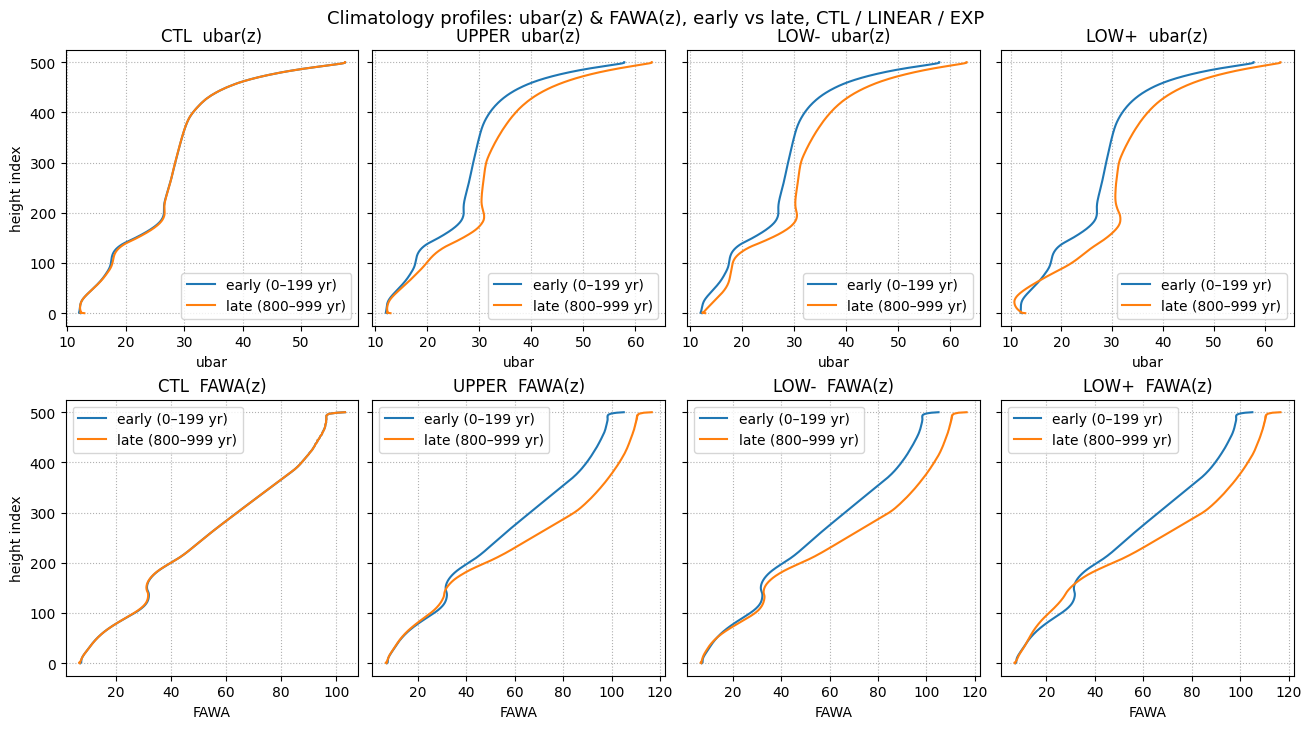

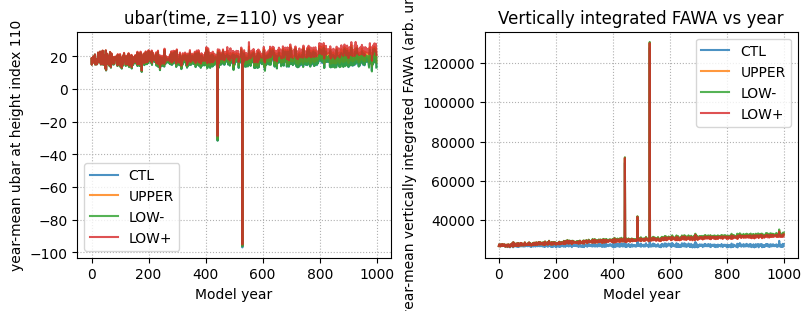

In [18]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# =========================
# 0. 
# =========================

nyear = 1000        # 1000 
base = "/scratch/smliu01/1d_model/climatechange/urad"

paths = {
    "ctl": {
        "u": f"{base}/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/ctl/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
    "upper": {
        "u": f"{base}/a_onlyup/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/a_onlyup/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
    "low-": {
        "u": f"{base}/low-/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/low-/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
    "low+": {
        "u": f"{base}/low+/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/low+/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
}

# early / late 
early_slice = slice(0, 200)       # 0–199 
late_slice  = slice(800, 1000)    # 800–999 

#  index0–500 
iz_level = 110    # 


# =========================
# 1.  ubar / fawa  reshape
# =========================

def load_ubar_fawa(path_u, path_a,
                   varname_u="ubar", varname_a="fawa",
                   nyear=1000):
    """
    path_u: uout  ubar(height, time)
    path_a: aout  fawa(height, time)

    :
      u_yth: (year, time_in_year, height)
      a_yth: (year, time_in_year, height)
      nt_per_year:  time 
      nz: 
    """
    # ----  ubar ----
    with Dataset(path_u) as nc_u:
        u_raw = np.array(nc_u[varname_u][:])   # (height, time)
        #  height  shape
        nheight, ntime = u_raw.shape
        #  (time, height)
        u_th = u_raw.T                          # (time, height)

    # ----  fawa ----
    with Dataset(path_a) as nc_a:
        a_raw = np.array(nc_a[varname_a][:])   # (height, time)
        a_th = a_raw.T                         # (time, height)

    # ---- reshape ----
    nt_total, nz = u_th.shape
    assert nt_total == a_th.shape[0] and nz == a_th.shape[1], "ubar/fawa "

    nt_per_year = nt_total // nyear
    assert nt_per_year * nyear == nt_total, "time  nyear "

    u_yth = u_th.reshape(nyear, nt_per_year, nz)  # (year, time, height)
    a_yth = a_th.reshape(nyear, nt_per_year, nz)

    return u_yth, a_yth, nt_per_year, nz


data = {}
nt_per_year_all = None

for tag in ["ctl", "upper", "low-", "low+"]:
    u_yth, a_yth, nt_per_year, nz = load_ubar_fawa(
        paths[tag]["u"], paths[tag]["a"],
        varname_u="ubar", varname_a="fawa",
        nyear=nyear
    )
    data[tag] = {
        "ubar": u_yth,    # (year, time, height)
        "fawa": a_yth,    # (year, time, height)
        "nz": nz
    }
    print(f"{tag}: ubar shape = {u_yth.shape}, fawa shape = {a_yth.shape}, nt_per_year = {nt_per_year}")

    if nt_per_year_all is None:
        nt_per_year_all = nt_per_year
    else:
        assert nt_per_year_all == nt_per_year, " nt_per_year "

#  index 0..nz-1
z_index = np.arange(nz)

#  iz_level 
if iz_level < 0 or iz_level >= nz:
    raise ValueError(f"iz_level={iz_level}  [0, {nz-1}] ")


# =========================
# 2. 
# =========================

def clim_profile(field_yth, year_slice):
    """
    field_yth: (year, time, height)
    year_slice: slice  slice(0,200)  slice(800,1000)
    :  climatology profile (height,)
    """
    return field_yth[year_slice, :, :].mean(axis=(0, 1))

def level_mean_time_series(field_yth, iz, year_slice=None):
    """
     iz  time series
    field_yth: (year, time, height)
    iz: int,  index
    year_slice:  slice
    : (year,)  time series
    """
    if year_slice is None:
        sub = field_yth[:, :, iz]   # (year, time)
    else:
        sub = field_yth[year_slice, :, iz]
    return sub.mean(axis=1)

def vert_int_time_series(field_yth, year_slice=None):
    """
     time  height 
     (year,) time series
    """
    if year_slice is None:
        sub = field_yth[:, :, :]   # (year, time, height)
    else:
        sub = field_yth[year_slice, :, :]
    #  -> (year, height) height 
    return sub.mean(axis=1).sum(axis=1)


# =========================
# 3. ubar(z) & FAWA(z)early vs late
# =========================

fig, axes = plt.subplots(2, 4, figsize=(13, 7), sharey=True, constrained_layout=True)

for j, tag in enumerate(["ctl", "upper", "low-", "low+"]):
    u_yth = data[tag]["ubar"]
    a_yth = data[tag]["fawa"]

    u_early = clim_profile(u_yth, early_slice)    # (height,)
    u_late  = clim_profile(u_yth, late_slice)
    a_early = clim_profile(a_yth, early_slice)
    a_late  = clim_profile(a_yth, late_slice)

    # ubar(z)
    ax = axes[0, j]
    ax.plot(u_early, z_index, label="early (0–199 yr)")
    ax.plot(u_late,  z_index, label="late (800–999 yr)")
    ax.set_title(f"{tag.upper()}  ubar(z)")
    ax.set_xlabel("ubar")
    if j == 0:
        ax.set_ylabel("height index")
    ax.invert_yaxis()
    ax.grid(True, linestyle=":")
    ax.legend()

    # FAWA(z)
    ax = axes[1, j]
    ax.plot(a_early, z_index, label="early (0–199 yr)")
    ax.plot(a_late,  z_index, label="late (800–999 yr)")
    ax.set_title(f"{tag.upper()}  FAWA(z)")
    ax.set_xlabel("FAWA")
    if j == 0:
        ax.set_ylabel("height index")
    ax.invert_yaxis()
    ax.grid(True, linestyle=":")
    ax.legend()

plt.suptitle("Climatology profiles: ubar(z) & FAWA(z), early vs late, CTL / LINEAR / EXP",
             y=1.02, fontsize=13)
# plt.savefig("ubar_fawa_profiles_early_late_ctl_linear_exp.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 4.  ubar   FAWA 
# =========================

years = np.arange(nyear)

fig, axes = plt.subplots(1, 2, figsize=(8,3), constrained_layout=True)

# (a) ubar(iz_level)  vs year
ax = axes[0]
for tag, color in zip(["ctl", "upper", "low-", "low+"], ["C0", "C1", "C2", "C3"]):
    u_yth = data[tag]["ubar"]
    u_level_ts = level_mean_time_series(u_yth, iz_level)
    ax.plot(years, u_level_ts, label=tag.upper(), alpha=0.8)
ax.set_xlabel("Model year")
ax.set_ylabel(f"year-mean ubar at height index {iz_level}")
ax.set_title(f"ubar(time, z={iz_level}) vs year")
ax.grid(True, linestyle=":")
ax.legend()

# (b) FAWA  sum_zvs year
ax = axes[1]
for tag, color in zip(["ctl", "upper", "low-", "low+"], ["C0", "C1", "C2", "C3"]):
    a_yth = data[tag]["fawa"]
    fawa_int_ts = vert_int_time_series(a_yth)
    ax.plot(years, fawa_int_ts, label=tag.upper(), alpha=0.8)
ax.set_xlabel("Model year")
ax.set_ylabel("year-mean vertically integrated FAWA (arb. units)")
ax.set_title("Vertically integrated FAWA vs year")
ax.grid(True, linestyle=":")
ax.legend()

# plt.savetxt("years.txt", years)  #  time series 
# plt.savefig("ubar_level_fawaInt_vs_year_ctl_linear_exp.png", dpi=300, bbox_inches="tight")
plt.show()


=== Control ===
  total events = 679, mean freq ~ 0.526
=== Top ===
  total events = 533, mean freq ~ 0.425
=== Top + Bottom ===
  total events = 640, mean freq ~ 0.500
=== Top - Bottom ===
  total events = 414, mean freq ~ 0.339
Layer-mean ΔuRAD:
  upper layer = 32.16-49.92 km, nlev = 90
  low/mid layer = 10.00-31.96 km, nlev = 111
ΔuRAD ranges:
  Top - Control: +0.000 to +9.118 m/s
  (Top + Bottom) - Top: +0.000 to +3.748 m/s
  (Top - Bottom) - Top: -3.748 to +0.000 m/s


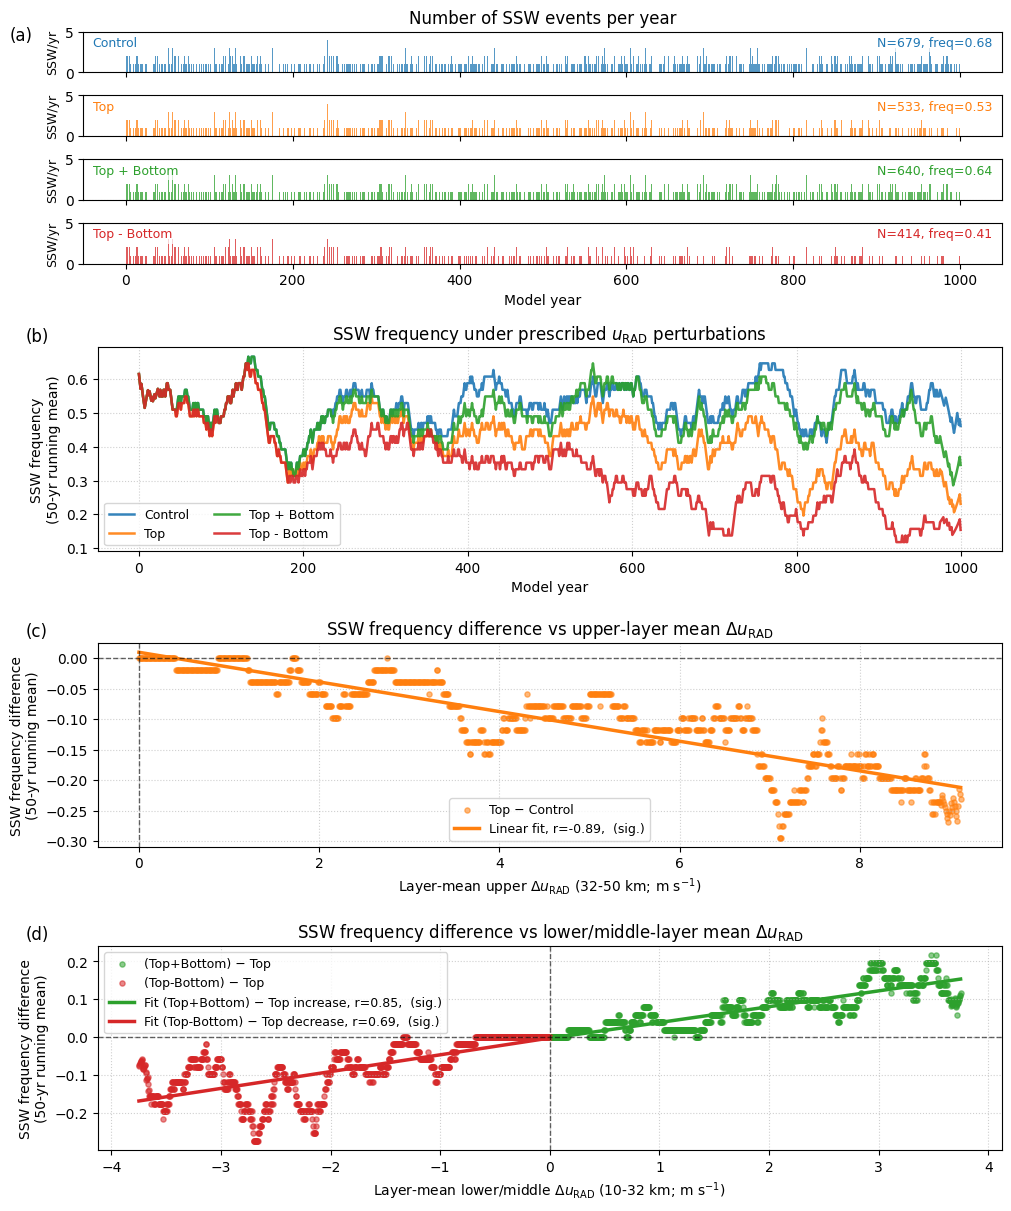

In [23]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =====================================================
# 0.  1D  ubar -> ERA5  ubp,date
#    count_ssw_events_from_ubar_legacy 
# =====================================================

def model_ubar_to_era5_like_inputs(
    ubar_model,
    level_index,
    years,
    steps_per_year,
    start_year=1979
):
    """
    
      ubp:  shape = (years, 992)  6-hourly Oct–May 
      date: list[list[str]]
    """
    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, " years*steps_per_year "

    u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

    tgt_len = 992
    src_x = np.arange(steps_per_year, dtype=float)
    tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        ubp[y] = np.interp(tgt_x, src_x, u[y])

    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]
    date = [[None] * tgt_len for _ in range(years)]

    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1
        assert k == tgt_len

    return ubp, date


# =====================================================
# 1.  & 
# =====================================================

nyear = 1000
steps_per_year = 160
level_index = 110
start_year = 1979

base = "/scratch/smliu01/1d_model/climatechange/urad"

paths_u = {
    "ctl":   f"{base}/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    "upper": f"{base}/a_onlyup/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    "low-":  f"{base}/low-/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    "low+":  f"{base}/low+/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
}

display_names = {
    "ctl":   "Control",
    "upper": "Top",
    "low-":  "Top + Bottom",
    "low+":  "Top - Bottom",
}

plot_order = ["ctl", "upper", "low-", "low+"]
plot_colors = {
    "ctl": "C0",
    "upper": "C1",
    "low-": "C2",
    "low+": "C3",
}

dmax_for_ssw = 992
DMAX_REF_FOR_DAYS = 992.0
WIN_YEARS = 50


# =====================================================
# 2.  nc  SSW flags & events
# =====================================================

def compute_ssw_flags_from_nc(
    path_u,
    level_index,
    years,
    steps_per_year,
    start_year=1979
):
    with Dataset(path_u) as nc:
        ubar_model = np.array(nc["ubar"][:])

    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, "time  years*steps_per_year"

    ubp_model, date_model = model_ubar_to_era5_like_inputs(
        ubar_model,
        level_index=level_index,
        years=years,
        steps_per_year=steps_per_year,
        start_year=start_year
    )

    dmax = ubp_model.shape[1]
    u_all_flat = ubp_model.reshape(-1)

    n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
        u_all_flat,
        n_per_year=dmax,
        years=years,
        dmax_ref=DMAX_REF_FOR_DAYS,
        min_gap_days=10.0,
        min_gap_onset_days=20.0,
        min_duration_days=2.0,
        use_djf_only=False,
        exclude_onset_indices=None,
        date_2d=date_model,
        enforce_march10_cutoff=True,
        return_debug=True,
    )

    flags = np.zeros(years, dtype=int)
    for (s, e) in events:
        iy = s // dmax
        if 0 <= iy < years:
            flags[iy] = 1

    return flags, events, debug


# =====================================================
# 3.  SSW
# =====================================================

ssw_flags = {}
ssw_events = {}
ssw_debug = {}

for tag in plot_order:
    print(f"=== {display_names[tag]} ===")
    flags, events, debug = compute_ssw_flags_from_nc(
        paths_u[tag],
        level_index=level_index,
        years=nyear,
        steps_per_year=steps_per_year,
        start_year=start_year
    )
    ssw_flags[tag] = flags
    ssw_events[tag] = events
    ssw_debug[tag] = debug
    print(f"  total events = {len(events)}, mean freq ~ {flags.mean():.3f}")

years_arr = np.arange(nyear)


# =====================================================
# 4. 50  SSW 
# =====================================================

def running_mean_edgeaware(x, win):
    x = np.asarray(x, float)
    n = x.size
    half = win // 2
    out = np.empty(n)

    for i in range(n):
        i0 = max(0, i - half)
        i1 = min(n, i + half + 1)
        out[i] = x[i0:i1].mean()

    return out

ssw_freq = {
    tag: running_mean_edgeaware(ssw_flags[tag], WIN_YEARS)
    for tag in plot_order
}


# =====================================================
# 5.  SSW 
# =====================================================

def counts_per_year_from_events(events, years, dmax):
    counts = np.zeros(years, dtype=int)
    for (s, e) in events:
        iy = s // dmax
        if 0 <= iy < years:
            counts[iy] += 1
    return counts

counts = {}
counts_total = {}

for tag in plot_order:
    counts[tag] = counts_per_year_from_events(
        ssw_events[tag],
        years=nyear,
        dmax=dmax_for_ssw
    )
    counts_total[tag] = np.sum(counts[tag])


# =====================================================
# 6. SSW frequency differences
# =====================================================

# upper effect: Upper-only - Control
df_upper = ssw_freq["upper"] - ssw_freq["ctl"]

# low/mid effect: relative to Upper-only
df_lowinc = ssw_freq["low-"] - ssw_freq["upper"]
df_lowdec = ssw_freq["low+"] - ssw_freq["upper"]


# =====================================================
# 7.  uRAD layer-mean ΔuRAD
# =====================================================

base_urad = "/scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments"

paths_urad = {
    "ctl":   f"{base_urad}/urad_ctl_timevarying.nc",
    "upper": f"{base_urad}/urad_A_upper_only_timevarying.nc",
    "low-":  f"{base_urad}/urad_C_upper_plus_lowmid_comp_timevarying.nc",
    "low+":  f"{base_urad}/urad_D_upper_plus_lowmid_enhance_timevarying.nc",
}

def read_urad_yearmean_layer(
    path,
    zmin_km,
    zmax_km,
    include_lower=True,
    include_upper=True
):
    with Dataset(path) as ds:
        urad = np.asarray(ds["urad"][:], dtype=float)
        height = np.asarray(ds["height"][:], dtype=float)

    if urad.ndim != 3:
        raise ValueError(
            f"urad should be 3D: (height, year, time), current shape={urad.shape}"
        )

    if include_lower:
        mask_low = height >= zmin_km
    else:
        mask_low = height > zmin_km

    if include_upper:
        mask_high = height <= zmax_km
    else:
        mask_high = height < zmax_km

    idx_selected = np.where(mask_low & mask_high)[0]

    if len(idx_selected) == 0:
        raise ValueError(
            f"No height levels found in range {zmin_km}-{zmax_km} km. "
            f"height range is {height.min()}-{height.max()} km."
        )

    z_selected = height[idx_selected]
    urad_layer = urad[idx_selected, :, :]

    # average over height and seasonal time, keep year
    yearmean_layer = np.nanmean(urad_layer, axis=(0, 2))

    return yearmean_layer, z_selected, idx_selected


#  uRAD  32 km 
z_upper_min_km = 32.0
z_upper_max_km = 50.0

z_lowmid_min_km = 10.0
z_lowmid_max_km = 32.0

# upper ΔuRAD: Upper-only - Control, 32–50 km
urad_ctl_upper, z_upper_selected, idx_upper_selected = read_urad_yearmean_layer(
    paths_urad["ctl"],
    z_upper_min_km,
    z_upper_max_km,
    include_lower=True,
    include_upper=True
)

urad_upper_upper, _, _ = read_urad_yearmean_layer(
    paths_urad["upper"],
    z_upper_min_km,
    z_upper_max_km,
    include_lower=True,
    include_upper=True
)

du_upper_layer = urad_upper_upper - urad_ctl_upper


# low/mid ΔuRAD:
# low- / low+ relative to upper-only, 10 <= z < 32 km
urad_upper_lowmid, z_lowmid_selected, idx_lowmid_selected = read_urad_yearmean_layer(
    paths_urad["upper"],
    z_lowmid_min_km,
    z_lowmid_max_km,
    include_lower=True,
    include_upper=False
)

urad_lowinc_lowmid, _, _ = read_urad_yearmean_layer(
    paths_urad["low-"],
    z_lowmid_min_km,
    z_lowmid_max_km,
    include_lower=True,
    include_upper=False
)

urad_lowdec_lowmid, _, _ = read_urad_yearmean_layer(
    paths_urad["low+"],
    z_lowmid_min_km,
    z_lowmid_max_km,
    include_lower=True,
    include_upper=False
)

du_lowinc_layer = urad_lowinc_lowmid - urad_upper_lowmid
du_lowdec_layer = urad_lowdec_lowmid - urad_upper_lowmid

print("Layer-mean ΔuRAD:")
print(
    f"  upper layer = {z_upper_selected.min():.2f}-{z_upper_selected.max():.2f} km, "
    f"nlev = {len(z_upper_selected)}"
)
print(
    f"  low/mid layer = {z_lowmid_selected.min():.2f}-{z_lowmid_selected.max():.2f} km, "
    f"nlev = {len(z_lowmid_selected)}"
)

print("ΔuRAD ranges:")
print(
    f"  Top - Control: "
    f"{np.nanmin(du_upper_layer):+.3f} to {np.nanmax(du_upper_layer):+.3f} m/s"
)
print(
    f"  (Top + Bottom) - Top: "
    f"{np.nanmin(du_lowinc_layer):+.3f} to {np.nanmax(du_lowinc_layer):+.3f} m/s"
)
print(
    f"  (Top - Bottom) - Top: "
    f"{np.nanmin(du_lowdec_layer):+.3f} to {np.nanmax(du_lowdec_layer):+.3f} m/s"
)


# =====================================================
# 8. 
# =====================================================

fit_upper = linregress(du_upper_layer, df_upper)
fit_lowinc = linregress(du_lowinc_layer, df_lowinc)
fit_lowdec = linregress(du_lowdec_layer, df_lowdec)

sig_upper = fit_upper.pvalue < 0.05
sig_lowinc = fit_lowinc.pvalue < 0.05
sig_lowdec = fit_lowdec.pvalue < 0.05

upper_title_sig = " (sig.)" if sig_upper else ""
lowmid_title_sig = " (sig.)" if (sig_lowinc or sig_lowdec) else ""

upper_fit_sig = " (sig.)" if sig_upper else ""
lowinc_fit_sig = " (sig.)" if sig_lowinc else ""
lowdec_fit_sig = " (sig.)" if sig_lowdec else ""


# =====================================================
# 9. 
# =====================================================

fig = plt.figure(figsize=(10, 12), constrained_layout=True)

gs = fig.add_gridspec(
    4, 1,
    height_ratios=[1.2, 0.8, 0.8, 0.8],
    hspace=0.08
)

# -----------------------------------------------------
# (a)  SSW  panel
# -----------------------------------------------------
subgs_a = gs[0, 0].subgridspec(4, 1, hspace=0.03)
axes_a = [fig.add_subplot(subgs_a[i, 0]) for i in range(4)]

for i, tag in enumerate(plot_order):
    ax = axes_a[i]

    ax.bar(
        years_arr,
        counts[tag],
        width=1.0,
        color=plot_colors[tag],
        alpha=0.75
    )

    # y 
    ax.set_ylabel("SSW/yr", fontsize=9)
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    ax.set_ylim(0, 5)

    # model 
    ax.text(
        0.01, 0.88,
        display_names[tag],
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=9,
        color=plot_colors[tag],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2)
    )

    # total events  mean frequency
    ax.text(
        0.99, 0.88,
        f"N={counts_total[tag]}, freq={counts_total[tag] / nyear:.2f}",
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=9,
        color=plot_colors[tag],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2)
    )

    if i < 3:
        ax.tick_params(labelbottom=False)

axes_a[-1].set_xlabel("Model year")
axes_a[0].set_title("Number of SSW events per year", fontsize=12)

axes_a[0].text(
    -0.08, 1.13, "(a)",
    transform=axes_a[0].transAxes,
    fontsize=12,
    va="top",
    ha="left"
)


# -----------------------------------------------------
# (b) 50-year running mean SSW frequency
# -----------------------------------------------------
ax_b = fig.add_subplot(gs[1, 0])

for tag in plot_order:
    ax_b.plot(
        years_arr,
        ssw_freq[tag],
        label=display_names[tag],
        color=plot_colors[tag],
        alpha=0.9,
        linewidth=1.8
    )

ax_b.set_xlabel("Model year")
ax_b.set_ylabel(f"SSW frequency\n({WIN_YEARS}-yr running mean)")
ax_b.set_title(r"SSW frequency under prescribed $u_{\mathrm{RAD}}$ perturbations", fontsize=12)
ax_b.grid(True, linestyle=":", alpha=0.6)
ax_b.legend(fontsize=9, ncol=2)

ax_b.text(
    -0.08, 1.10, "(b)",
    transform=ax_b.transAxes,
    fontsize=12,
    va="top",
    ha="left"
)


# -----------------------------------------------------
# (c) Upper-layer mean ΔuRAD vs SSW frequency difference
# -----------------------------------------------------
ax_c = fig.add_subplot(gs[2, 0])

ax_c.scatter(
    du_upper_layer,
    df_upper,
    s=14,
    alpha=0.55,
    color=plot_colors["upper"],
    label="Top − Control"
)

xfit = np.linspace(np.nanmin(du_upper_layer), np.nanmax(du_upper_layer), 200)
yfit = fit_upper.slope * xfit + fit_upper.intercept

ax_c.plot(
    xfit,
    yfit,
    color=plot_colors["upper"],
    linewidth=2.5,
    label=(
        f"Linear fit, r={fit_upper.rvalue:.2f}, "
        f"{upper_fit_sig}"
    )
)

ax_c.axhline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
ax_c.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)

ax_c.set_xlabel(
    rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({z_upper_selected.min():.0f}-{z_upper_selected.max():.0f} km; m s$^{{-1}}$)"
)
ax_c.set_ylabel(f"SSW frequency difference\n({WIN_YEARS}-yr running mean)")
ax_c.set_title(
    rf"SSW frequency difference vs upper-layer mean $\Delta u_{{\mathrm{{RAD}}}}$",
    fontsize=12
)
ax_c.grid(True, linestyle=":", alpha=0.6)
ax_c.legend(fontsize=9)

ax_c.text(
    -0.08, 1.10, "(c)",
    transform=ax_c.transAxes,
    fontsize=12,
    va="top",
    ha="left"
)


# -----------------------------------------------------
# (d) Lower/middle-layer mean ΔuRAD vs SSW frequency difference
# -----------------------------------------------------
ax_d = fig.add_subplot(gs[3, 0])

ax_d.scatter(
    du_lowinc_layer,
    df_lowinc,
    s=14,
    alpha=0.55,
    color=plot_colors["low-"],
    label="(Top+Bottom) − Top"
)

ax_d.scatter(
    du_lowdec_layer,
    df_lowdec,
    s=14,
    alpha=0.55,
    color=plot_colors["low+"],
    label="(Top-Bottom) − Top"
)

# fit low/mid increase
xfit_inc = np.linspace(np.nanmin(du_lowinc_layer), np.nanmax(du_lowinc_layer), 200)
yfit_inc = fit_lowinc.slope * xfit_inc + fit_lowinc.intercept

ax_d.plot(
    xfit_inc,
    yfit_inc,
    color=plot_colors["low-"],
    linewidth=2.5,
    label=(
        f"Fit (Top+Bottom) − Top increase, r={fit_lowinc.rvalue:.2f}, "
        f"{lowinc_fit_sig}"
    )
)

# fit low/mid decrease
xfit_dec = np.linspace(np.nanmin(du_lowdec_layer), np.nanmax(du_lowdec_layer), 200)
yfit_dec = fit_lowdec.slope * xfit_dec + fit_lowdec.intercept

ax_d.plot(
    xfit_dec,
    yfit_dec,
    color=plot_colors["low+"],
    linewidth=2.5,
    label=(
        f"Fit (Top-Bottom) − Top decrease, r={fit_lowdec.rvalue:.2f}, "
        f"{lowdec_fit_sig}"
    )
)

ax_d.axhline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
ax_d.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)

ax_d.set_xlabel(
    rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({z_lowmid_selected.min():.0f}-{z_lowmid_selected.max():.0f} km; m s$^{{-1}}$)"
)
ax_d.set_ylabel(f"SSW frequency difference\n({WIN_YEARS}-yr running mean)")
ax_d.set_title(
    rf"SSW frequency difference vs lower/middle-layer mean $\Delta u_{{\mathrm{{RAD}}}}$",
    fontsize=12
)
ax_d.grid(True, linestyle=":", alpha=0.6)
ax_d.legend(fontsize=9)

ax_d.text(
    -0.08, 1.10, "(d)",
    transform=ax_d.transAxes,
    fontsize=12,
    va="top",
    ha="left"
)


# =====================================================
# 10. 
# =====================================================

fig.savefig(
    "combined_ssw_urad_4panel_vertical.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()



In [20]:
# =====================================================
# 5.5   urad  10hPa Oct–May  urad
# =====================================================

import netCDF4 as nc
import numpy as np

#  ud_ssw_interp 
with nc.Dataset('/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/urad_501_1000.nc') as ds:
    ud_ssw_interp = ds.variables['urad'][:]

with nc.Dataset('/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/climatechange/urad/no_z/urad_trend_interp.nc') as ds:
    urad_trend_interp = ds.variables['urad'][:]

with nc.Dataset('/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/climatechange/urad/z/urad_trend_interp_z.nc') as ds:
    urad_trend_interp_z = ds.variables['urad'][:]


# =====================================================
#  (<=10hPa) urad  + 
# =====================================================
zdim = ud_ssw_interp.shape[0]
iz_10 = level_index          # 10 hPa  index

mask_low  = np.arange(zdim) <= iz_10     # ≤10 hPa
mask_up = (np.arange(zdim) > iz_10) & (np.arange(zdim) < 190)  # >10 hPa  zdim<190

# 
H = 7.0  # km
w_low = np.exp(-hhh[mask_low] / H)
w_low = w_low / w_low.sum()

# 
w_up = np.ones(mask_up.sum())
w_up = w_up / w_up.sum()

def urad_index_low(urad):
    # urad: (z, year, time)
    u_zt = urad[mask_low,:,:].mean(axis=2)       # (z_low, year)
    return (w_low[:,None] * u_zt).sum(axis=0)   # (year,)

def urad_index_up(urad):
    u_zt = urad[mask_up,:,:].mean(axis=2)       # (z_up, year)
    return (w_up[:,None] * u_zt).sum(axis=0)

# 
I_low_ctl     = urad_index_low(ud_ssw_interp)
I_low_uniform = urad_index_low(urad_trend_interp)
I_low_zdep    = urad_index_low(urad_trend_interp_z)

I_up_ctl      = urad_index_up(ud_ssw_interp)
I_up_uniform  = urad_index_up(urad_trend_interp)
I_up_zdep     = urad_index_up(urad_trend_interp_z)

#  − 
shear_ctl     = I_up_ctl     - I_low_ctl
shear_uniform = I_up_uniform - I_low_uniform
shear_zdep    = I_up_zdep    - I_low_zdep

from scipy.stats import linregress, pearsonr

#  no_z (uniform) 
x_uniform = abs(shear_uniform)
y_uniform = ssw_freq["no_z"] - ssw_freq["ctl"]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_uniform, y_uniform)
fit_uniform = slope1 * x_uniform + intercept1

#  z_dep 
x_zdep = abs(shear_zdep)
y_zdep = ssw_freq["z"] - ssw_freq["ctl"]
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_zdep, y_zdep)
fit_zdep = slope2 * x_zdep + intercept2

# 
corr1, pval1 = pearsonr(x_uniform, y_uniform)
corr2, pval2 = pearsonr(x_zdep, y_zdep)

def signif_str(p, threshold=0.05):
    if p < threshold:
        return "sig."
    else:
        return "NOT sig."

print(f"Pearson correlation (UNIFORM): r={corr1:.2f}, p={pval1:.3g} ({signif_str(pval1)})")
print(f"Pearson correlation (Z-DEP):   r={corr2:.2f}, p={pval2:.3g} ({signif_str(pval2)})")

shear_ctl0 = shear_ctl.mean()     # CTL 

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)

# UNIFORM: no_z
sc1 = ax.scatter(x_uniform, y_uniform,
           s=8, alpha=0.6, label="UNIFORM - CTL", color='C1')
ax.plot(x_uniform, fit_uniform, color='C1', lw=3, linestyle='-',
        label=f"Linear fit (UNIFORM), r={corr1:.2f}, ({signif_str(pval1)})")

# Z-DEP: z
sc2 = ax.scatter(x_zdep, y_zdep,
           s=8, alpha=0.6, label="Z-DEP - CTL", color='C2')
ax.plot(x_zdep, fit_zdep, color='C2', lw=3, linestyle='-',
        label=f"Linear fit (Z-DEP), r={corr2:.2f}, ({signif_str(pval2)})")

# CTL 
ax.axvline(abs(shear_ctl0), color="k", linestyle="--", linewidth=1.0,
           label="CTL shear index")

ax.set_xlabel("Shear index = upper urad – lower urad (m/s)")
ax.set_ylabel(f"SSW frequency diff ({WIN_YEARS}-yr running mean)")
ax.set_title("SSW frequency vs vertical shear in urad")
ax.grid(True, linestyle=":")
ax.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/urad_501_1000.nc'

beta_L, beta_S, beta_0 = 0.021545900406195653 -0.008291002134209191 -0.4137671149358313


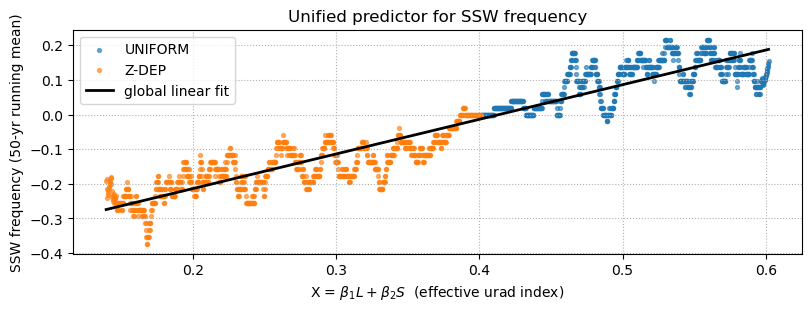

In [ ]:
import numpy as np

#  & 
L_uni = I_low_uniform      # shape: (nyear,)
L_z   = I_low_zdep
S_uni = shear_uniform
S_z   = shear_zdep

# SSW 50 
F_uni = ssw_freq["no_z"] - ssw_freq["ctl"]
F_z   = ssw_freq["z"] - ssw_freq["ctl"]

# 
L_all = np.concatenate([L_uni, L_z])
S_all = np.concatenate([S_uni, S_z])
F_all = np.concatenate([F_uni, F_z])

X_design = np.vstack([L_all, S_all, np.ones_like(L_all)]).T  # [L, S, 1]

# : F ≈ β1 * L + β2 * S + β0
beta, *_ = np.linalg.lstsq(X_design, F_all, rcond=None)
beta_L, beta_S, beta_0 = beta
print("beta_L, beta_S, beta_0 =", beta_L, beta_S, beta_0)

#  urad  X
X_uni = beta_L * L_uni + beta_S * S_uni
X_z   = beta_L * L_z   + beta_S * S_z

#  X  F 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3), constrained_layout=True)

ax.scatter(X_uni, F_uni, s=8, alpha=0.6, label="UNIFORM")
ax.scatter(X_z,   F_z,   s=8, alpha=0.6, label="Z-DEP")

# 
X_all = np.concatenate([X_uni, X_z])
A_all = np.vstack([X_all, np.ones_like(X_all)]).T
k, b = np.linalg.lstsq(A_all, F_all, rcond=None)[0]
xx = np.linspace(X_all.min(), X_all.max(), 200)
ax.plot(xx, k*xx + b, 'k-', lw=2, label="global linear fit")

ax.set_xlabel(r"X = $\beta_1 L + \beta_2 S$  (effective urad index)")
ax.set_ylabel(f"SSW frequency ({WIN_YEARS}-yr running mean)")
ax.set_title("Unified predictor for SSW frequency")
ax.grid(True, linestyle=":")
ax.legend()
plt.show()


Pearson correlation (UNIFORM): r=0.69, p=6.6e-144 (sig.)
Pearson correlation (Z-DEP):   r=0.81, p=5.8e-235 (sig.)


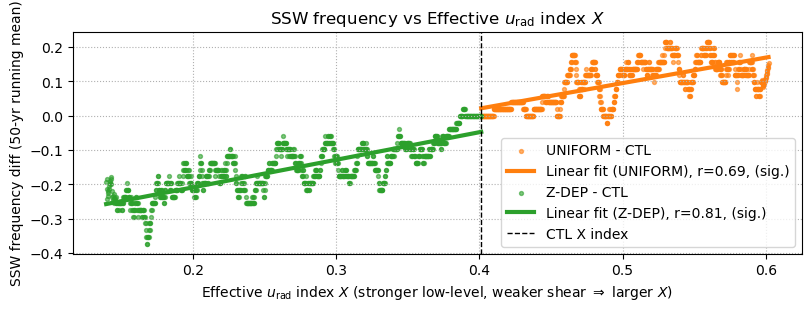

In [ ]:
from scipy.stats import linregress, pearsonr

# # ---------- 1.  beta  X index ----------
# beta_L = 0.013193973034524523
# beta_S = -0.01128628142331576
# beta_0 = 0.1973320464531101   # 

# L: low-level urad index, S: shear index
L_ctl     = I_low_ctl
L_uniform = I_low_uniform
L_zdep    = I_low_zdep

S_ctl     = shear_ctl
S_uniform = shear_uniform
S_zdep    = shear_zdep

#  unified index X = beta_L * L + beta_S * S
X_uniform = beta_L * L_uniform + beta_S * S_uniform
X_zdep    = beta_L * L_zdep    + beta_S * S_zdep
X_ctl     = beta_L * L_ctl     + beta_S * S_ctl

X_ctl0 = X_ctl.mean()   # CTL  X

# ---------- 2.  experiment  ----------
x_uniform = X_uniform
y_uniform = ssw_freq["no_z"] - ssw_freq["ctl"]

slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_uniform, y_uniform)
fit_uniform = slope1 * x_uniform + intercept1

x_zdep = X_zdep
y_zdep = ssw_freq["z"] - ssw_freq["ctl"]

slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_zdep, y_zdep)
fit_zdep = slope2 * x_zdep + intercept2

# ---------- 3.  ----------
corr1, pval1 = pearsonr(x_uniform, y_uniform)
corr2, pval2 = pearsonr(x_zdep, y_zdep)

def signif_str(p, threshold=0.05):
    return "sig." if p < threshold else "NOT sig."

print(f"Pearson correlation (UNIFORM): r={corr1:.2f}, p={pval1:.3g} ({signif_str(pval1)})")
print(f"Pearson correlation (Z-DEP):   r={corr2:.2f}, p={pval2:.3g} ({signif_str(pval2)})")

# ---------- 4.  ----------
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)

# UNIFORM: no_z
sc1 = ax.scatter(x_uniform, y_uniform,
                 s=8, alpha=0.6, label="UNIFORM - CTL", color='C1')
ax.plot(x_uniform, fit_uniform, color='C1', lw=3, linestyle='-',
        label=f"Linear fit (UNIFORM), r={corr1:.2f}, ({signif_str(pval1)})")

# Z-DEP: z
sc2 = ax.scatter(x_zdep, y_zdep,
                 s=8, alpha=0.6, label="Z-DEP - CTL", color='C2')
ax.plot(x_zdep, fit_zdep, color='C2', lw=3, linestyle='-',
        label=f"Linear fit (Z-DEP), r={corr2:.2f}, ({signif_str(pval2)})")

# CTL  X 
ax.axvline(X_ctl0, color="k", linestyle="--", linewidth=1.0,
           label="CTL X index")

ax.set_xlabel(r"Effective $u_{\rm rad}$ index $X$ (stronger low-level, weaker shear $\Rightarrow$ larger $X$)")
ax.set_ylabel(f"SSW frequency diff ({WIN_YEARS}-yr running mean)")
ax.set_title(r"SSW frequency vs Effective $u_{\rm rad}$ index $X$ ")
ax.grid(True, linestyle=":")
ax.legend()

plt.show()


In [ ]:
beta_S

np.float64(-0.008291002134209191)

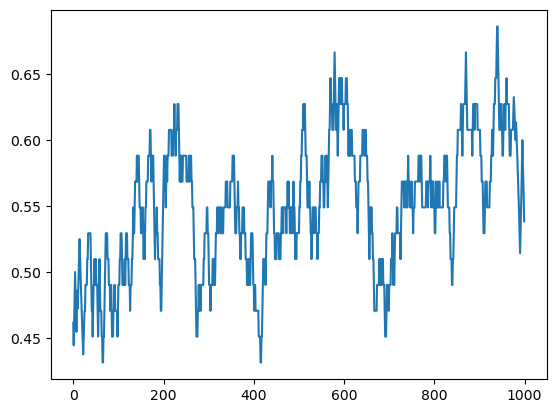

In [ ]:
plt.plot(ssw_freq["no_z"])

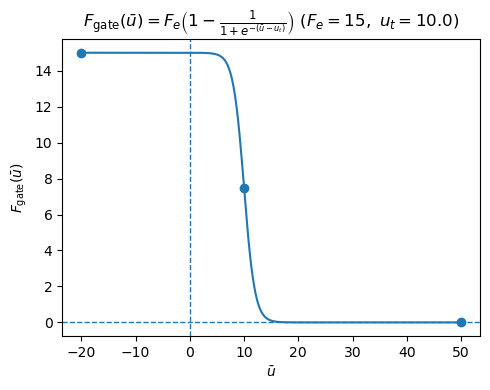

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 
Fe = 15
ut = 10.0

# ubar  -20  50
ubar = np.linspace(-20, 50, 500)

F_gate = Fe * (1 - 1.0 / (1.0 + np.exp(-(ubar - ut))))

plt.figure(figsize=(5,4))
plt.plot(ubar, F_gate)
plt.axhline(0, linewidth=1,linestyle='--')
plt.axvline(0, linewidth=1,linestyle='--')

plt.xlabel(r'$\bar{u}$')
plt.ylabel(r'$F_{\mathrm{gate}}(\bar{u})$')
plt.title(r'$F_{\mathrm{gate}}(\bar{u}) = F_e\left(1-\frac{1}{1+e^{-(\bar{u}-u_t)}}\right)$ ' 
          + rf'($F_e={Fe},\ u_t={ut}$)')

# 
u_points = np.array([-20.0, ut, 50.0])
F_points = Fe * (1 - 1.0 / (1.0 + np.exp(-(u_points - ut))))
plt.scatter(u_points, F_points)

plt.tight_layout()
plt.show()
